In [1]:
# 导入必要的库
import pandas as pd
import jieba
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# 读取CSV文件
df = pd.read_csv('merged_output.csv')

# 提取弹幕信息列
danmu_messages = df['弹幕信息'].tolist()

# 加载停用词
stop_words = set(stopwords.words('chinese'))


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Actor.D\AppData\Local\Temp\jieba.cache
Loading model cost 0.749 seconds.
Prefix dict has been built successfully.


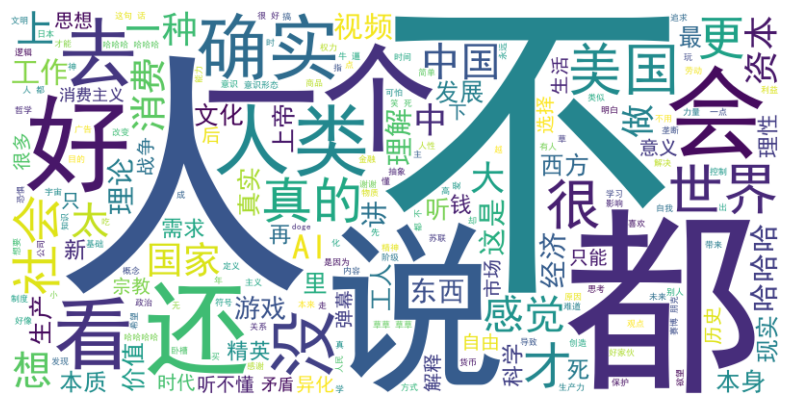

In [2]:

# 分词并去除停用词
def preprocess(text):
    words = jieba.cut(text)
    return ' '.join([word for word in words if word not in stop_words and word.strip() != ''])

# 预处理所有弹幕信息
processed_danmu = [preprocess(message) for message in danmu_messages]

# 将分词结果添加到DataFrame
df['分词结果'] = processed_danmu

# 绘制词云

# 分词并去除停用词
def preprocess(text):
    words = jieba.cut(text)
    return ' '.join([word for word in words if word not in stop_words and word.strip() != ''])

# 预处理所有弹幕信息
processed_danmu = [preprocess(message) for message in danmu_messages]

# 将分词结果添加到DataFrame
df['分词结果'] = processed_danmu

# 绘制词云
all_words = ' '.join(processed_danmu)
wordcloud = WordCloud(font_path='simhei.ttf', width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# 保存处理后的弹幕信息和分词结果到CSV文件
df.to_csv('processed_danmu.csv', index=False)